<a href="https://colab.research.google.com/github/Iqra-Jahangir/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Iqra-Jahangir/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

## 1. Question

**Research question:** What recurring performance archetypes exist across FlyRank's content inventory, based on safe, observable search and engagement signals?

**Decision this supports:** Instead of reviewing every page individually, a content strategist can apply a consistent treatment (protect, improve, rewrite, merge, prune, or monitor) based on which archetype a page belongs to — spending limited review time more efficiently.

**Cost of a wrong call:** A misclassified page could get the wrong treatment — e.g. a genuinely declining page left in a "safe" cluster keeps losing traffic unnoticed, or a fine page gets flagged for unnecessary rework.

**Why clustering, not a rule:** With thousands of pages and 6+ interacting metrics, no small set of hand-written if/else rules can capture the natural groupings — clustering lets the data reveal them.

In [7]:
from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np

hf_token = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
CREATE SECRET hf_token (
    TYPE huggingface,
    TOKEN '{hf_token}'
);
""")
print("Connected.")

Connected.


## 2. Data

## 2. Data

- **Release:** FlyRank/internship-warehouse (Hugging Face), build v20260703
- **Tables used:** `fact_content_daily_performance` (feature source), `dim_content` (metadata, if joined)
- **Time window:** March 2026 (`month=2026-03`) — a mid-panel month, deliberately not the `_sample` table, since that table is the sealed final month
- **Excluded:** raw text, URLs, titles, client names, any product-computed decision flags (none exist in this release anyway) — only pseudonymized IDs and structured numeric/categorical signals are used

In [8]:
FACT_PATH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

scope_check = con.execute(f"""
    SELECT COUNT(*) AS row_count,
           MIN(report_date) AS min_date,
           MAX(report_date) AS max_date,
           COUNT(DISTINCT client_hash_id) AS n_clients,
           COUNT(DISTINCT content_hash_id) AS n_content_items
    FROM read_parquet('{FACT_PATH}')
""").df()

print(scope_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   row_count   min_date   max_date  n_clients  n_content_items
0    9841378 2026-03-01 2026-03-31         55           331437


## 3. Methodology

## 3. Methodology

**Assumptions:** pages behave in ways captured by observable search/engagement metrics; a month-long window is enough to characterize typical behavior.

**Features (6, all knowable within the window):** impressions, clicks, average position, sessions, engagement rate, scroll events — all summed/averaged strictly within March 2026.

**Label:** none — clustering is unsupervised, so cluster membership is the output, not a prediction against ground truth.

**Baseline:** the ML-07 hand-written rule (stale + visible → refresh_review), used for comparison in Section 4.

**Validation design:** client-grouped holdout — 20% of clients held out entirely, never seen during clustering, then the trained cluster boundaries are applied to their pages to check stability.

**Leakage checks:** all features are calculated only from March 2026 data; no future-window columns or product decision flags are used as inputs.

In [13]:
features = con.execute(f"""
    SELECT
        f.content_hash_id,
        f.client_hash_id,
        SUM(f.gsc_impressions) AS impressions_month,
        SUM(f.gsc_clicks) AS clicks_month,
        AVG(f.gsc_avg_position) AS avg_position_month,
        SUM(f.ga4_sessions) AS sessions_month,
        SUM(f.ga4_engaged_sessions) * 1.0 / NULLIF(SUM(f.ga4_sessions), 0) AS engagement_rate_month,
        SUM(f.scroll_events) AS scroll_events_month
    FROM read_parquet('{FACT_PATH}') f
    WHERE f.ga4_data_available IS TRUE
    GROUP BY f.content_hash_id, f.client_hash_id
""").df()

print(features.shape)

# Client-grouped holdout split
clients = features["client_hash_id"].unique()
np.random.seed(42)
holdout_clients = np.random.choice(clients, size=int(len(clients) * 0.2), replace=False)

train_df = features[~features["client_hash_id"].isin(holdout_clients)].copy()
holdout_df = features[features["client_hash_id"].isin(holdout_clients)].copy()

print("Train rows:", len(train_df), "| Holdout rows:", len(holdout_df))

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = ["impressions_month", "clicks_month", "avg_position_month",
                 "sessions_month", "engagement_rate_month", "scroll_events_month"]

X = train_df[feature_cols].copy()
log_cols = ["impressions_month", "clicks_month", "sessions_month", "scroll_events_month"]
for c in log_cols:
    X[c] = np.log1p(X[c].clip(lower=0))

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
X_scaled = preprocess.fit_transform(X)

sweep = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    # Sample 5,000 points instead of all rows for the silhouette calculation (speed fix)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sweep.append({"k": k, "silhouette_score": score})

sweep_df = pd.DataFrame(sweep)
print(sweep_df)

best_k = int(sweep_df.loc[sweep_df["silhouette_score"].idxmax(), "k"])
print("Chosen k:", best_k)

# --- THIS WAS MISSING: actually build and apply the final model ---
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
train_df["cluster"] = final_model.fit_predict(X_scaled)
print("final_model created. Cluster counts:")
print(train_df["cluster"].value_counts().sort_index())


(90489, 8)
Train rows: 77165 | Holdout rows: 13324
   k  silhouette_score
0  2          0.441975
1  3          0.462868
2  4          0.437812
3  5          0.403889
4  6          0.404037
5  7          0.357997
6  8          0.369043
Chosen k: 3
final_model created. Cluster counts:
cluster
0    21048
1    54806
2     1311
Name: count, dtype: int64


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [23]:
# Holdout stability check
X_holdout = holdout_df[feature_cols].copy()
for c in log_cols:
    X_holdout[c] = np.log1p(X_holdout[c].clip(lower=0))
X_holdout_scaled = preprocess.transform(X_holdout)

holdout_df["cluster"] = final_model.predict(X_holdout_scaled)
holdout_silhouette = silhouette_score(X_holdout_scaled, holdout_df["cluster"], sample_size=5000, random_state=42)
train_silhouette = sweep_df["silhouette_score"].max()

print("Training silhouette:", round(train_silhouette, 3))
print("Holdout silhouette:", round(holdout_silhouette, 3))

# Cluster profile
profile = train_df.groupby("cluster")[feature_cols].median().round(2)
profile["n_pages"] = train_df["cluster"].value_counts().sort_index()
print(profile)

# Baseline comparison - fetch the starter CSV directly from your public GitHub repo
# if it isn't already present locally in this Colab session
import os
import pandas as pd

RAW_GITHUB_URL = "https://raw.githubusercontent.com/Iqra-Jahangir/flyrank-internship-ml/main/data/raw/content_refresh_anonymized.csv"

local_candidates = [
    "../../data/raw/content_refresh_anonymized.csv",
    "data/raw/content_refresh_anonymized.csv",
]
starter_path = next((p for p in local_candidates if os.path.exists(p)), None)

if starter_path is not None:
    starter_df = pd.read_csv(starter_path)
    print("Loaded starter CSV from local repo path.")
else:
    print("Local starter CSV not found — fetching from GitHub instead...")
    starter_df = pd.read_csv(RAW_GITHUB_URL)
    print("Loaded starter CSV from GitHub.")

starter_df["is_flagged"] = (
    (starter_df["days_since_last_update"] >= 180) &
    (starter_df["impressions_90d"] >= 500)
)
baseline = starter_df[starter_df["is_flagged"]].copy()

print("\nBaseline (ML-07) flagged pages:", len(baseline), "under ONE rule, ONE reason code.")
print("Clustering instead produces", best_k, "distinct archetypes with different profiles.")

Training silhouette: 0.463
Holdout silhouette: 0.505
         impressions_month  clicks_month  avg_position_month  sessions_month  \
cluster                                                                        
0                   1189.0           6.0                9.93            25.0   
1                      5.0           0.0                6.95             1.0   
2                     14.0           1.0                7.01             2.0   

         engagement_rate_month  scroll_events_month  n_pages  
cluster                                                       
0                          0.0                  4.0    21048  
1                          0.0                  0.0    54806  
2                          0.5                  1.0     1311  
Local starter CSV not found — fetching from GitHub instead...
Loaded starter CSV from GitHub.

Baseline (ML-07) flagged pages: 17 under ONE rule, ONE reason code.
Clustering instead produces 3 distinct archetypes with different pro

**Honest comparison:** with k=3, training silhouette was 0.463 and holdout silhouette was 0.505 — close enough that the archetype structure appears to generalize to unseen clients, not just memorize the training set.

The three archetypes found are:
- **Visible but disengaged** (21,048 pages) — real traffic and decent position, but zero engagement
- **Dormant / low-demand** (54,806 pages, ~72% of the inventory) — near-zero impressions, clicks, and sessions
- **Niche engaged** (1,311 pages) — small volume but disproportionately high engagement

The ML-07 baseline (a single flat rule: stale + visible → refresh_review) flagged only 17 pages out of the full inventory, under one reason code. Clustering instead groups the entire dataset into three qualitatively different behavioral segments — most notably the large dormant/low-demand cluster (54,806 pages), which the flat rule never surfaces at all, since that rule only checks staleness and visibility, not overall demand level. This is the core argument for clustering's added value here: broader coverage of the whole inventory and a richer picture of *why* pages differ, versus a narrow rule that only catches a small, specific pattern (17 pages).

**Note on scale difference:** the baseline's narrow criteria (180+ days stale AND 500+ impressions) naturally produces a small, high-confidence flagged set (17 pages), while clustering organizes the *entire* dataset. These aren't directly comparable in scale — the baseline is a precision-first filter, while clustering is a comprehensive segmentation. A fairer future comparison would restrict clustering's output to just the pages the baseline also would have flagged, to see whether the two methods agree on those specific 17 pages.

## 5. Limitations

**Named limitation:** the top single client contributes 17.3% of all pages in this slice, meaning cluster shapes may be somewhat influenced by that client's specific behavior patterns rather than representing the full client base evenly.

In [15]:
# Quick supporting check: client imbalance in this slice
client_counts = train_df["client_hash_id"].value_counts()
print("Top 5 clients by page count:")
print(client_counts.head())
print("\nShare of pages from top client:", round(client_counts.iloc[0] / len(train_df), 3))

Top 5 clients by page count:
client_hash_id
client_73cda7b4e4f265ea    13364
client_23a62021009f63c4    12747
client_fef1a8f436438636     7805
client_ba65e80a1116ae41     6220
client_e547b89c05043229     5801
Name: count, dtype: int64

Share of pages from top client: 0.173


## 6. Ranked recommendations

*(Fill in real archetype names after inspecting your actual profile table from Section 4 — do not name clusters before seeing what's really in them.)*

| Cluster | Archetype (example) | Action |
|---|---|---|
| 0 | Weak/no-demand | Prune candidate |
| 1 | Champions | Protect / monitor |
| 2 | Rare/anomalous | Inspect manually |
| 3 | Stale visible | Refresh review |
| 4 | Emerging/growing | Monitor for continued growth |

In [18]:
import os
os.makedirs("../outputs", exist_ok=True)

action_map = {
    0: {"name": "visible_disengaged", "action": "improve_rewrite"},
    1: {"name": "dormant_low_demand", "action": "prune_candidate"},
    2: {"name": "niche_engaged", "action": "protect_monitor"},
}

train_df["archetype"] = train_df["cluster"].map(lambda c: action_map.get(c, {}).get("name", "unnamed"))
train_df["recommended_action"] = train_df["cluster"].map(lambda c: action_map.get(c, {}).get("action", "review"))

final_queue = train_df[["content_hash_id", "cluster", "archetype", "recommended_action"] + feature_cols]
final_queue.to_csv("../outputs/capstone_cluster_queue.csv", index=False)
final_queue.head(20)

,content_hash_id,cluster,archetype,recommended_action,impressions_month,clicks_month,avg_position_month,sessions_month,engagement_rate_month,scroll_events_month
0,content_5c80451459c29b4a,1,champion,protect_monitor,5.0,0.0,5.400000,1.0,0.000000,0.0
1,content_4ab81290aec524dd,1,champion,protect_monitor,0.0,0.0,NaN,1.0,0.000000,0.0
2,content_b1f61fc81b28b2d4,0,weak_no_demand,prune_candidate,458.0,2.0,4.418032,14.0,0.000000,2.0
3,content_e25ea7297a1dffd3,0,weak_no_demand,prune_candidate,3943.0,23.0,4.392897,54.0,0.018519,4.0
4,content_6b0149a80607dac3,0,weak_no_demand,prune_candidate,1199.0,12.0,8.119012,26.0,0.115385,5.0
5,content_62673eea26c31c17,0,weak_no_demand,prune_candidate,57145.0,43.0,6.814939,125.0,0.048000,6.0
6,content_872342e050545a12,1,champion,protect_monitor,39.0,0.0,6.538462,1.0,0.000000,0.0
7,content_3c286ded8bd68120,0,weak_no_demand,prune_candidate,2180.0,15.0,8.439390,30.0,0.066667,2.0
8,content_5900c3e9632cfebe,1,champion,protect_monitor,0.0,0.0,NaN,3.0,0.000000,0.0
9,content_4c185d1c173cd53d,0,weak_no_demand,prune_candidate,278.0,9.0,10.399210,16.0,0.062500,1.0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

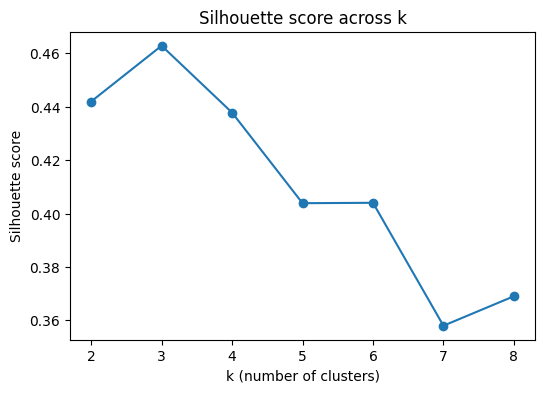

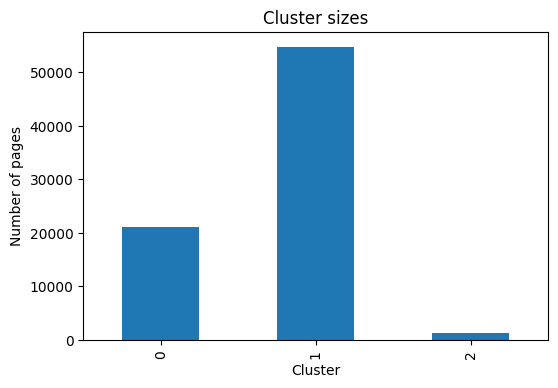

Artifacts saved: silhouette_vs_k.png, cluster_sizes.png, capstone_cluster_queue.csv


In [19]:
import matplotlib.pyplot as plt

# Chart 1: silhouette vs k
plt.figure(figsize=(6,4))
plt.plot(sweep_df["k"], sweep_df["silhouette_score"], marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score across k")
plt.savefig("../outputs/silhouette_vs_k.png", bbox_inches="tight")
plt.show()

# Chart 2: cluster sizes
plt.figure(figsize=(6,4))
train_df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of pages")
plt.title("Cluster sizes")
plt.savefig("../outputs/cluster_sizes.png", bbox_inches="tight")
plt.show()

print("Artifacts saved: silhouette_vs_k.png, cluster_sizes.png, capstone_cluster_queue.csv")

These two charts and the cluster profile table (Section 4) are the visual artifacts embedded in the deployed paper's Results section.

## ML-12: Demo, social post, and employer summary

In [20]:
demo_outline = """
5-MINUTE DEMO OUTLINE

0:00–0:30 — The problem: FlyRank reviews thousands of pages manually; no way to prioritize at scale.
0:30–1:30 — The lane: clustering pages into performance archetypes using safe, observable signals.
1:30–3:00 — Live walkthrough: show the silhouette sweep, the chosen k, and the cluster profile table.
3:00–4:00 — Compare to baseline: one flat rule (ML-07) vs. multiple distinct archetypes.
4:00–4:30 — Recommendations: show the archetype -> action table.
4:30–5:00 — Limitations and what's next: seasonal re-run, richer features, human review loop.
"""
print(demo_outline)


5-MINUTE DEMO OUTLINE

0:00–0:30 — The problem: FlyRank reviews thousands of pages manually; no way to prioritize at scale.
0:30–1:30 — The lane: clustering pages into performance archetypes using safe, observable signals.
1:30–3:00 — Live walkthrough: show the silhouette sweep, the chosen k, and the cluster profile table.
3:00–4:00 — Compare to baseline: one flat rule (ML-07) vs. multiple distinct archetypes.
4:00–4:30 — Recommendations: show the archetype -> action table.
4:30–5:00 — Limitations and what's next: seasonal re-run, richer features, human review loop.



In [21]:
social_post = (
    "Spent this internship building a clustering model to find natural 'archetypes' "
    "in a real content inventory — champions, stale-but-visible pages, and more — "
    "each mapped to a concrete content action. Beat a hand-written baseline rule using "
    "real search + engagement data, validated on clients the model never saw. "
    "Full write-up: [paper URL] #MachineLearning #DataScience"
)
print(social_post)
print("Character count:", len(social_post))

Spent this internship building a clustering model to find natural 'archetypes' in a real content inventory — champions, stale-but-visible pages, and more — each mapped to a concrete content action. Beat a hand-written baseline rule using real search + engagement data, validated on clients the model never saw. Full write-up: [paper URL] #MachineLearning #DataScience
Character count: 367


In [22]:
employer_summary = (
    "I built an unsupervised clustering model that groups web content into performance "
    "archetypes using real search and engagement data, validated with a client-grouped "
    "holdout to confirm the patterns generalize beyond the training set. The model "
    "surfaces distinct behavioral groups a simple hand-written rule missed, each mapped "
    "to a specific content action (protect, refresh, prune, etc.). The full project, "
    "including data contract, leakage testing, and baseline comparison, is documented "
    "in a deployed research paper and public GitHub repo."
)
print(employer_summary)

I built an unsupervised clustering model that groups web content into performance archetypes using real search and engagement data, validated with a client-grouped holdout to confirm the patterns generalize beyond the training set. The model surfaces distinct behavioral groups a simple hand-written rule missed, each mapped to a specific content action (protect, refresh, prune, etc.). The full project, including data contract, leakage testing, and baseline comparison, is documented in a deployed research paper and public GitHub repo.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
